In [1]:
import numpy as np
from datasets import Dataset

def generate_noise_dataset(num_samples: int, shape=(3, 224, 224)):
    data = {
        "image": [np.random.normal(0, 1, size=shape).astype(np.float32)
                  for _ in range(num_samples)],
        "captions": [[] for _ in range(num_samples)]
    }
    return Dataset.from_dict(data)

# example
ds = generate_noise_dataset(10)
ds.set_format(type="numpy", columns=["image"])
print(ds)
print(ds[0])

/home/elena/miniconda/envs/emcomm/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset({
    features: ['image', 'captions'],
    num_rows: 10
})
{'image': array([[[-4.6304636e-02, -1.5651904e+00,  3.0939227e-01, ...,
         -7.6179796e-01, -8.7787223e-01,  1.0215040e+00],
        [-5.9722906e-01,  1.0827881e+00, -1.7340067e-01, ...,
         -2.0437934e+00, -3.0536361e-02, -1.3669258e+00],
        [-1.0597832e+00,  2.2007432e+00, -1.6405258e-01, ...,
         -1.0798054e+00,  1.9756490e+00, -9.3622439e-02],
        ...,
        [-1.4026098e+00, -4.6006098e-01, -3.4352675e-01, ...,
         -2.1966945e-01, -9.6733905e-03,  1.3014524e+00],
        [ 3.2496008e-01,  2.5388114e+00, -9.2508376e-01, ...,
         -3.5578227e-01, -1.5683359e+00, -5.0802034e-01],
        [-8.0858278e-01, -9.7430074e-01, -6.2081283e-01, ...,
         -2.5547555e-01,  1.6236315e+00, -3.5377830e-01]],

       [[-2.8540522e-01, -1.0276759e+00, -3.4565973e-01, ...,
         -1.0019627e+00,  1.0118814e+00,  8.6292881e-01],
        [ 7.3341143e-01,  5.1845902e-01, -4.2921498e-01, ...,
      

In [12]:
# from datasets import Image

# ds = ds.cast_column("image", Image())

In [ ]:
# ds.save_to_disk("/home/elena/emcomm/datasets/gaussian_noise_dataset")

Saving the dataset (2/2 shards): 100%|██████████| 1000/1000 [00:05<00:00, 172.73 examples/s]


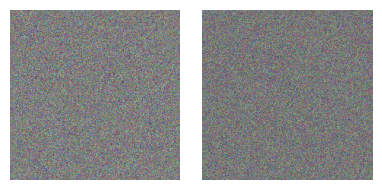

In [2]:
import random
import matplotlib.pyplot as plt

def show_random_images(dataset, n=10):
    indices = random.sample(range(len(dataset)), n)

    fig, axes = plt.subplots(1, n, figsize=(2*n, 2))
    
    for ax, idx in zip(axes, indices):
        img = dataset[idx]["image"]
        
        # (C, H, W) -> (H, W, C) for display
        if img.shape[0] in [1, 3]:
            img = img.transpose(1, 2, 0)

        # normalize for visualization (since values ~ N(0,1))
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)

        ax.imshow(img)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

# usage
show_random_images(ds, 2)

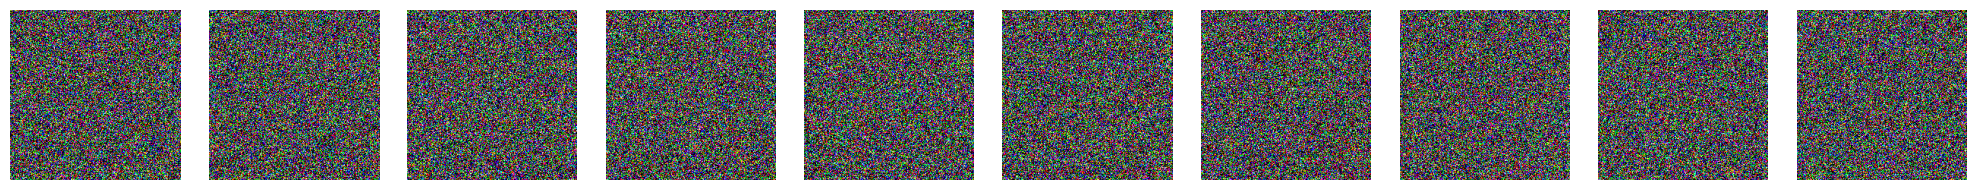

In [7]:
import random
import numpy as np
import torch
import matplotlib.pyplot as plt
from torchvision import transforms

# ImageNet normalization
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

normalize = transforms.Normalize(mean=mean.flatten(), std=std.flatten())

def show_normalized_images(dataset, n=10):
    indices = random.sample(range(len(dataset)), n)
    fig, axes = plt.subplots(1, n, figsize=(2*n, 2))

    for ax, idx in zip(axes, indices):
        img = torch.tensor(np.array(dataset[idx]["image"]), dtype=torch.float32)

        # normalize
        norm_img = normalize(img)

        # denormalize ONLY for visualization
        vis_img = norm_img * std + mean

        # clamp to valid range
        vis_img = vis_img.clamp(0, 1)

        # CHW -> HWC
        vis_img = vis_img.permute(1, 2, 0).numpy()

        ax.imshow(vis_img)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

# usage
show_normalized_images(ds, 10)